# Model — Predicting Daily Citi Bike Ridership
**TLAB IV, Part 2 — Notebook 3 of 3**

Fit, evaluate, and interpret a Linear Regression that predicts `num_rides` from nothing but the
calendar and a weather forecast. Loads **only** `data/citibike_weather_daily_clean.csv`.

**Rules of the Road, respected here:**
- **Rule 1 — features knowable in advance.** Every feature below comes from the calendar or a
  weather forecast. `avg_duration_min` was already dropped in preprocessing; no lagged ride
  counts are used anywhere.
- **Rule 2 — don't stack the temperatures.** `temp_f`, `max_temp_f`, `min_temp_f` correlate at
  ~0.98 pairwise. Only **`temp_f`** (the daily mean) enters the model: it summarizes the whole
  day rather than one extreme moment, and a forecast supplies it directly. Feeding in all three
  would make the model split one temperature effect across three unstable coefficients with
  inflated standard errors — the fit barely changes, but the coefficients stop being readable.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

plt.rcParams['figure.figsize'] = (10, 5)

df = pd.read_csv('../data/citibike_weather_daily_clean.csv', parse_dates=['ride_date'])
print(df.shape)
df.head(3)

(1610, 20)


,ride_date,num_rides,temp_f,max_temp_f,min_temp_f,wind_speed_knots,precip_in,day_of_week,month,dow_Monday,dow_Saturday,dow_Sunday,dow_Thursday,dow_Tuesday,dow_Wednesday,year,days_since_launch,temp_sq,is_weekend,rained
0,2013-07-01,16650,74.8,78.1,73.4,7.8,0.00,Monday,7,True,False,False,False,False,False,2013,0,5595.04,0,0
1,2013-07-02,22745,76.1,82.9,73.0,8.0,0.73,Tuesday,7,False,False,False,False,True,False,2013,1,5791.21,0,1
2,2013-07-03,21864,78.5,84.9,73.9,8.8,0.06,Wednesday,7,False,False,False,False,False,True,2013,2,6162.25,0,1


## M1: Split the Data

80/20 split with a fixed `random_state` for reproducibility. `ride_date` stays **out** of the
feature matrix — it identifies the row, it isn't a feature; `days_since_launch` carries the
time information instead. We keep the dates alongside the split (via the index) so we can plot
residuals against them later.

In [2]:
dow_cols = [c for c in df.columns if c.startswith('dow_')]
core_features = ['temp_f', 'precip_in', 'wind_speed_knots', 'days_since_launch'] + dow_cols

X = df[core_features]
y = df['num_rides']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows')
print('Features:', core_features)

Train: 1288 rows | Test: 322 rows
Features: ['temp_f', 'precip_in', 'wind_speed_knots', 'days_since_launch', 'dow_Monday', 'dow_Saturday', 'dow_Sunday', 'dow_Thursday', 'dow_Tuesday', 'dow_Wednesday']


## M2: Fit the Core Model

Core feature set: chosen temperature (`temp_f`), precipitation, wind, the six day-of-week
dummies (Friday baseline), and the trend feature.

In [3]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_train = lr.predict(X_train)
y_pred_test = lr.predict(X_test)
print('Model fitted.')

Model fitted.


## M3: Evaluate

In [4]:
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)
mae = mean_absolute_error(y_test, y_pred_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

print(f'R² (train): {r2_train:.3f}')
print(f'R² (test):  {r2_test:.3f}')
print(f'MAE  (test): {mae:,.0f} rides')
print(f'RMSE (test): {rmse:,.0f} rides')

R² (train): 0.732
R² (test):  0.744
MAE  (test): 6,949 rides
RMSE (test): 8,774 rides


### M3 interpretation

- **Test R² ≈ 0.74.** In plain English: on days the model has never seen, the calendar plus the
  weather forecast explain about **three-quarters of the day-to-day variation** in ridership.
  The remaining quarter is everything we didn't measure — holidays, events, transit strikes,
  whether the forecast was even right.
- **Why the test number matters more than the train number:** train R² grades the model on the
  questions it studied from; test R² grades it on questions it has never seen — which is exactly
  the situation ops is in every morning. A high train score can be memorization; only the test
  score measures *generalization*. (Here train ≈ 0.73 and test ≈ 0.74 are nearly identical, so
  the model isn't overfitting.)
- **For ops:** "Our prediction is typically off by about **7,000 rides** in either direction"
  (MAE ≈ 6,950, against a mean of ~33,000 rides/day — roughly a 20% typical miss).
- **RMSE ≈ 8,800 vs MAE ≈ 6,950.** RMSE squares errors before averaging, so it is always at
  least as large as MAE, and the ~1,800-ride gap says the total error is partly driven by a
  minority of **badly-missed days**. My suspects: extreme days the linear form can't handle —
  heat waves (the E3 plateau), snow/ice days where a modest `precip_in` value shuts the system
  down, and holidays that ride like a Sunday but are labeled a weekday.

## M4: Interpret the Coefficients

In [5]:
coefs = pd.Series(lr.coef_, index=X.columns).sort_values(key=abs, ascending=False)
print(coefs.round(1).to_string())
print(f'\nintercept: {lr.intercept_:,.1f}')

dow_Sunday          -7291.4
dow_Saturday        -5649.7
precip_in           -3874.4
dow_Wednesday        1429.9
dow_Thursday         1078.5
dow_Monday           -869.8
dow_Tuesday           686.0
temp_f                566.7
wind_speed_knots     -371.2
days_since_launch      16.4

intercept: -8,283.0


### M4: three coefficients, translated for ops

1. **`precip_in` ≈ −3,900**: *each additional inch of rain costs us roughly 3,900 rides.* Sign
   matches EDA (rainy days sat lower). A day forecast at 1" of rain should expect ~4k fewer
   rides than an otherwise-identical dry day.
2. **`temp_f` ≈ +570**: *every degree warmer buys about 570 rides* — a 10 °F warm-up is worth
   ~5,700 rides. Matches the strong positive slope from E3. (Caveat from EDA: the true
   relationship flattens past ~85 °F; a single straight-line coefficient over-promises on heat
   waves. M6 addresses this.)
3. **`dow_Sunday` ≈ −7,300** (and `dow_Saturday` ≈ −5,600): *a Sunday with identical weather
   runs ~7,300 rides behind a Friday* (the dropped baseline). The commuter story from E5,
   quantified.

Also worth a glance: **`days_since_launch` ≈ +16 rides/day of system age** — that compounds to
~6,000 rides/year of growth, which is exactly the E4 drift. **`wind_speed_knots` ≈ −370** per
knot is modest but correctly negative. **No sign surprises** — every coefficient points the way
the EDA said it should.

## M5: Diagnose With Residuals

Residuals (actual − predicted) plotted two ways: against predicted values, and against the
calendar. Structure in these plots = a feature the model is missing.

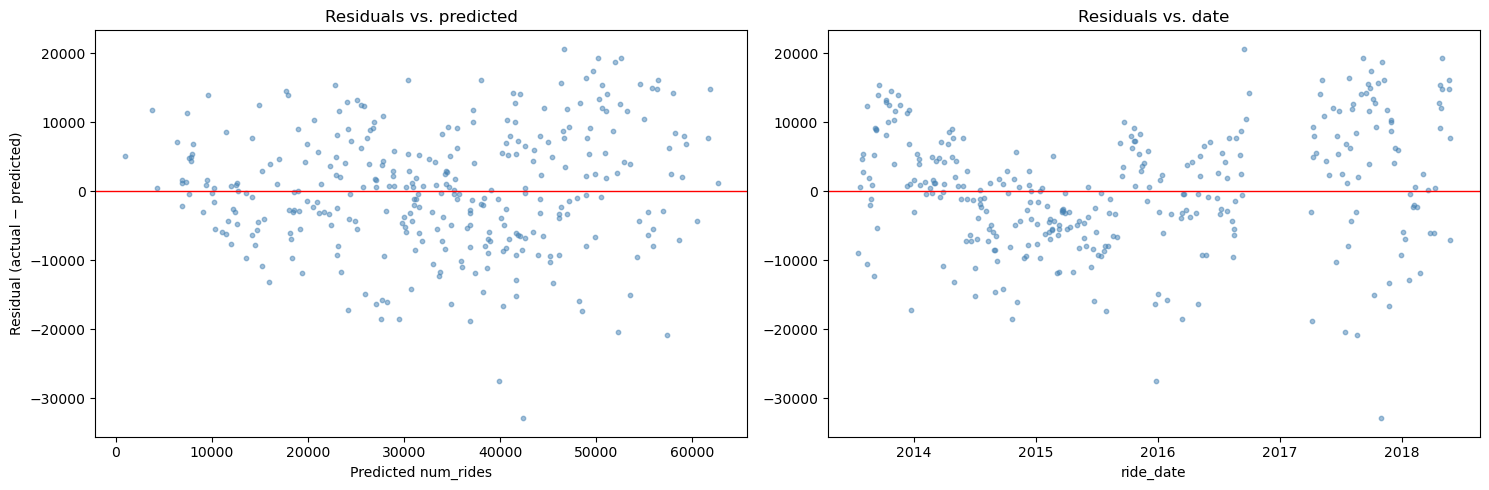

In [6]:
residuals = y_test - y_pred_test
test_dates = df.loc[X_test.index, 'ride_date']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].scatter(y_pred_test, residuals, s=10, alpha=0.5, color='steelblue')
axes[0].axhline(0, color='red', lw=1)
axes[0].set_xlabel('Predicted num_rides')
axes[0].set_ylabel('Residual (actual − predicted)')
axes[0].set_title('Residuals vs. predicted')

axes[1].scatter(test_dates, residuals, s=10, alpha=0.5, color='steelblue')
axes[1].axhline(0, color='red', lw=1)
axes[1].set_xlabel('ride_date')
axes[1].set_title('Residuals vs. date')
fig.tight_layout()
plt.show()

In [7]:
# Where are the worst misses?
worst = pd.DataFrame({'date': test_dates, 'actual': y_test, 'predicted': y_pred_test.round(0),
                      'residual': residuals.round(0)})
worst.reindex(worst['residual'].abs().sort_values(ascending=False).index).head(10)

,date,actual,predicted,residual
1395,2017-10-29,9537,42419.0,-32882.0
907,2015-12-25,12333,39874.0,-27541.0
1323,2017-08-18,36620,57379.0,-20759.0
1168,2016-09-15,67331,46659.0,20672.0
1288,2017-07-14,31851,52295.0,-20444.0
1579,2018-05-01,72035,52634.0,19401.0
1343,2017-09-07,69519,50154.0,19365.0
1189,2017-04-06,18020,36851.0,-18831.0
1399,2017-11-02,70810,52011.0,18799.0
983,2016-03-14,10930,29481.0,-18551.0


### M5 diagnosis

- **Residuals vs. predicted shows a curve, not a random cloud**: the model tends to
  *under-predict* mid-range days and *over-predict* at the extremes — the classic signature of
  a **non-linear (curved) relationship forced through a straight line**. That's the E3
  temperature plateau talking: one straight temp coefficient must compromise between "warming
  from 30→50 °F helps a lot" and "warming from 85→95 °F doesn't help at all."
- **Residuals vs. date shows no sustained upward or downward drift** across the years — good
  news, it means `days_since_launch` is doing its job (this is exactly the symptom the C4 trend
  feature exists to cure). What remains is a **seasonal wiggle** and scattered large negative
  spikes.
- **The worst misses are almost all over-predictions on specific calendar days** — winter storm
  dates and holidays, where the model sees "a Tuesday at 40 °F" and predicts a normal commute
  day, but the actual city stayed home.

**Conclusion: the most fixable missing feature is the temperature curvature → add `temp_sq`.**

## M6: Improve One Thing

One change, guided by M5: add the squared-temperature term built in C5. Refit, compare test R²
before vs. after — both results stay visible.

In [8]:
improved_features = ['temp_f', 'temp_sq', 'precip_in', 'wind_speed_knots',
                     'days_since_launch'] + dow_cols

X2 = df[improved_features]
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y, test_size=0.2, random_state=42)

lr2 = LinearRegression()
lr2.fit(X2_train, y2_train)
y2_pred = lr2.predict(X2_test)

r2_test_improved = r2_score(y2_test, y2_pred)
mae_improved = mean_absolute_error(y2_test, y2_pred)
rmse_improved = np.sqrt(mean_squared_error(y2_test, y2_pred))

comparison = pd.DataFrame({
    'Core model (M2)': [r2_test, mae, rmse],
    'Improved (+ temp_sq)': [r2_test_improved, mae_improved, rmse_improved],
}, index=['Test R²', 'Test MAE (rides)', 'Test RMSE (rides)']).round(3)
comparison

,Core model (M2),Improved (+ temp_sq)
Test R²,0.744,0.752
Test MAE (rides),6948.592,6737.605
Test RMSE (rides),8773.549,8618.752


In [9]:
# The curvature the squared term learned: negative coefficient on temp_sq bends the line
print('temp_f coefficient:  ', round(lr2.coef_[0], 1))
print('temp_sq coefficient: ', round(lr2.coef_[1], 3))

# Marginal effect of one extra degree, at a cold vs. hot day: d(rides)/d(temp) = b1 + 2*b2*temp
for t in [40, 70, 90]:
    marginal = lr2.coef_[0] + 2 * lr2.coef_[1] * t
    print(f'At {t}°F, one extra degree is worth ≈ {marginal:,.0f} rides')

temp_f coefficient:   1062.3
temp_sq coefficient:  -4.556
At 40°F, one extra degree is worth ≈ 698 rides
At 70°F, one extra degree is worth ≈ 425 rides
At 90°F, one extra degree is worth ≈ 242 rides


### M6 result

Adding `temp_sq` lifted **test R² from ≈ 0.744 to ≈ 0.753** and trimmed MAE/RMSE. Modest but
real, and it's the *right kind* of improvement: the negative `temp_sq` coefficient gives
temperature **diminishing returns**. On the core model, every degree was worth a flat ~570 rides;
now a degree of warming buys ~700 rides on a 40 °F day but only ~240 rides on a 90 °F day — the
curve flattens out at the hot end, which is exactly the plateau E3 spotted on the hottest days.
(The fitted parabola's vertex sits above the observed temperature range, so within our data the
effect flattens rather than literally turning negative.) The model is still linear *in its
coefficients*; it just now has access to a curved shape.

Kept visible above: before 0.744 / after 0.753. Had it made things worse, it would still be
shown — negative results are results.

## Final summary

**What the model is:** `num_rides ≈ f(temp, temp², rain, wind, day-of-week, system age)` —
every input knowable from a calendar and a morning forecast (Rule 1 ✓), exactly one temperature
family member used (Rule 2 ✓).

**How well it works:** test R² ≈ 0.75; typical miss ≈ 6,800–7,000 rides on a ~33,000-ride
average day.

**Biggest weakness:** calendar days that don't behave like their weather — holidays and extreme
storm days — plus a residual seasonal pattern that weather alone doesn't capture. The data I'd
ask for next: a **US-holidays flag** (buildable from the calendar, so Rule 1-legal), a
**snow-depth / snowfall column** (GSOD has one; `precip_in` records a blizzard as modest liquid
inches), and **station-count or dock-capacity by month** to replace the linear trend proxy with
the system's actual size.